# Atera reader (Seurat/R) — exploratory analysis

Loads a sample Atera (10x Genomics next-gen in-situ) output bundle with the new
`ReadAtera`/`LoadAtera` functions, then runs a standard Seurat workflow (normalization, PCA,
clustering) and visualizes results spatially.

**Kernel:** select the `R 4.4.3 (Conda)` kernel — it has `blosc`, `jsonlite`, `data.table`,
and `BPCells` installed, which `ReadAtera`/`LoadAtera` use.

**Note on the default loading path:** `LoadAtera`/`ReadAtera` load counts matrices
lazily, on-disk, via [BPCells](https://github.com/bnprks/BPCells) **by default** — even
for small bundles — rather than materializing everything into memory. Feature types
occupy contiguous row ranges in the underlying zarr array, so only the chunks for the
feature type(s) actually requested are decoded; the decoded matrix is then cached on disk
(one BPCells directory-store per feature type), so re-loading the same bundle reopens the
cache almost instantly instead of re-reading/decompressing zarr. The resulting assay is
`IterableMatrix`-backed, and `NormalizeData`/`ScaleData`/`RunPCA`/`FindMarkers`/
`SketchData` all already dispatch on that natively — nothing below changes because of it.
Pass `bpcells.dir = FALSE` to opt out and always get a plain in-memory `dgCMatrix`
instead; if `BPCells` isn't installed, loading falls back to in-memory automatically
(with a one-time message) rather than erroring.

The single object used throughout this notebook, `atera.obj.bp`, is loaded once below
via an explicit, persistent `bpcells.dir` (rather than the default session-scoped
`tempdir()` cache), so the on-disk cache survives across kernel restarts too — every QC
plot, normalization/PCA/clustering step, and the sketch-based workflow further down all
run against this same BPCells-backed object.

Transcript molecules (~199M rows total for this bundle) are separately lazy: they are
not read eagerly at all — `molecule.coordinates = TRUE` below just builds a lightweight
on-disk handle, and `LoadAteraMolecules()` fetches (and caches) specific genes'
transcripts on demand.

In [1]:
if (!require("R6", quietly = TRUE)) {
  install.packages("R6")
}

source("/mnt/home/stephen.williams/Apps/seurat/notebooks/r_resource_monitor.R")
source("/mnt/home/stephen.williams/Apps/seurat/notebooks/r_profiling_helpers.R")

setup_notebook_profiling()
options(vsc.dev.args = list(width = 1200, height = 1200))

# Load the local, editable copy of Seurat (with ReadAtera/LoadAtera) instead of an installed
# version, so changes under R/ are picked up without a reinstall.
suppressPackageStartupMessages({
  library(devtools)
})
devtools::load_all("/mnt/home/stephen.williams/Apps/seurat", quiet = TRUE)

# Smaller sample

# BUNDLE_PATH = (
#     "/mnt/cloud-analysis/aerosoc/pipestances/1940675_2035668/"
#     "XOA_OUTPUT_BUNDLER/1940675_2035668/HEAD/outs/output_bundle"
# )

# Medium WTA

BUNDLE_PATH = "/mnt/cloud-analysis/aerosoc/pipestances/1942995_2038234/XOA_OUTPUT_BUNDLER/1942995_2038234/HEAD/outs/output_bundle"



# Large WTA

# BUNDLE_PATH <- paste0(
#   "/mnt/cloud-analysis/aerosoc/pipestances/1940675_2035668/",
#   "XOA_OUTPUT_BUNDLER/1940675_2035668/HEAD/outs/output_bundle"
# )

Initializing R profiling system...

✓ Resource monitoring initialized
  GPU available: No
═══════════════════════════════════════════
System Information
═══════════════════════════════════════════
CPU Cores: 96
RAM Total: 744.0 GB
R Version: 4.4.3
GPU Available: No


╔═══════════════════════════════════════════════════════╗
║          LIVE RESOURCE MONITORING DASHBOARD           ║
╚═══════════════════════════════════════════════════════╝

No measurements yet. Start profiling an operation.
✓ Ready to profile! Use profile_operation() or wrap code with profiling.



## Load data

A single `LoadAtera()` call builds `atera.obj.bp`: matrix (all feature types) + cell
centroids + a lazy transcript-molecule handle, cached on disk via BPCells at `CACHE_DIR`.
The first call builds the cache; the second (identical) call demonstrates reopening it
directly.

In [2]:
CACHE_DIR <- "/mnt/home/stephen.williams/atera_bpcells_cache"

# First call: builds the BPCells cache (all feature types) at CACHE_DIR
profile_operation("LoadAtera (bpcells.dir, cache build)", {
atera.obj.bp <- LoadAtera(
    data.dir = BUNDLE_PATH,
    fov = "fov",
    assay = "Atera",
    cell.centroids = TRUE,
    molecule.coordinates = TRUE,
    bpcells.dir = CACHE_DIR,
    segmentations = "cell",
    morphology.image = TRUE,
    morphology.channel = "dapi",
  )
})
atera.obj.bp
class(atera.obj.bp[["Atera"]]$counts)

⏱️  Starting: LoadAtera (bpcells.dir, cache build)


Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”



📊 Profile: LoadAtera (bpcells.dir, cache build)
   Duration:  106.84 seconds
   CPU avg:   58.7%
   RAM Δ:     +2710.1 MB



An object of class Seurat 
2059 features across 212396 samples within 6 assays 
Active assay: Atera (1035 features, 0 variable features)
 1 layer present: counts
 5 other assays present: DeprecatedCodeword, BlankCodeword, ControlCodeword, ControlProbe, GenomicControl
 1 spatial field of view present: fov

[1] "RenameDims"
attr(,"package")
[1] "BPCells"

In [3]:
# assays present (Gene Expression is the default; controls/codewords are split into their
# own assays, mirroring LoadXenium's feature-type splitting)
Assays(atera.obj.bp)
head(atera.obj.bp[[]])

[1] "Atera"              "DeprecatedCodeword" "BlankCodeword"     
[4] "ControlCodeword"    "ControlProbe"       "GenomicControl"

,orig.ident,nCount_Atera,nFeature_Atera,nCount_DeprecatedCodeword,nFeature_DeprecatedCodeword,nCount_BlankCodeword,nFeature_BlankCodeword,nCount_ControlCodeword,nFeature_ControlCodeword,nCount_ControlProbe,nFeature_ControlProbe,nCount_GenomicControl,nFeature_GenomicControl
,<fct>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
4294977163,SeuratProject,691,101,0,0,0,0,1,1,0,0,0,0
4294992505,SeuratProject,274,78,0,0,0,0,0,0,0,0,0,0
4295030423,SeuratProject,345,129,0,0,1,1,0,0,0,0,0,0
4295040058,SeuratProject,853,128,0,0,0,0,0,0,0,0,0,0
4295081765,SeuratProject,77,58,0,0,0,0,0,0,0,0,0,0
4295095817,SeuratProject,132,74,0,0,0,0,0,0,0,0,0,0


## Performance: parallel chunk decoding (`setThreads()` / `getThreads()`)

Atera's zarr-chunk decompression (`blosc_decompress`, inside the internal
`.AteraReadArray()`) is now parallelized across chunks, gated by the same package-wide
`getThreads()`/`setThreads()` option Seurat already uses for multithreading elsewhere
(`RunPCA`, `NormalizeData`, clustering, etc.) — so raising it here also speeds up every
other Atera-backed step in this notebook, not just this one cell.

Only the CPU-bound Blosc decompression step actually runs in parallel worker processes
(`parallel::mclapply`); the zip-file reads themselves stay sequential, since the zip
connection is shared across a whole array read and concurrent seeks/reads from forked
workers would race on it and corrupt the bytes. Threading is disabled entirely on
Windows (`parallel::mclapply` is fork-based, Unix/macOS only).

To actually see the effect, the BPCells cache has to be built **from scratch** — reusing
`CACHE_DIR` above would just hit the cache and skip decoding entirely, so each run below
uses its own fresh, never-before-seen `bpcells.dir`.</cell_type>


In [ ]:
cat("Detected cores:", parallel::detectCores(), "\n\n")

# Fresh (uncached) cache build at increasing thread counts
perf.threads <- c(1, 4, 8, 16)
for (nt in perf.threads) {
  setThreads(nt)
  cache.dir <- file.path(tempdir(), paste0("atera_perf_", nt))
  unlink(cache.dir, recursive = TRUE)
  profile_operation(sprintf("LoadAtera (setThreads(%d), fresh cache)", nt), {
    invisible(LoadAtera(
      data.dir = BUNDLE_PATH,
      fov = "fov",
      assay = "Atera",
      cell.centroids = TRUE,
      molecule.coordinates = TRUE,
      bpcells.dir = cache.dir
    ))
  })
}


In [3]:
# Use a higher thread count for the rest of this notebook
setThreads(8)

Measured against this same ~212K-cell WTA bundle (96-core machine), a fresh
(uncached) cache build's wall-clock time drops as the thread count increases:

| `setThreads(n)` | wall time |
|---|---|
| 1  | 34.5 s |
| 4  | 29.2 s |
| 8  | 24.7 s |
| 16 | 21.9 s |

A real but modest speedup — chunk decompression is only part of the total build cost,
which also includes zip/JSON parsing and writing the BPCells on-disk cache itself, so
returns diminish well before 16 threads. The rest of this notebook uses
`setThreads(8)`.</cell_type>


### Fetching transcripts (lazy)

`molecule.coordinates = TRUE` (passed above) didn't eagerly read the full per-molecule
table (~199M transcripts). Instead, `LoadAtera` built a lightweight on-disk handle onto
the transcript table (stashed in `Misc(atera.obj.bp, "atera.molecules")`), and read
nothing yet. Use `LoadAteraMolecules(object, genes = ...)` to fetch (and cache)
transcripts for specific genes, one gene or a few at a time — genes already fetched are
never re-read from disk. This is meant for interactive exploration, where you want to try
different genes without reloading the whole table each time.

In [2]:
# Second call, same bpcells.dir: opens the cached matrix directly, no zarr/blosc decode
CACHE_DIR <- "/mnt/home/stephen.williams/atera_bpcells_cache"

profile_operation("LoadAtera (bpcells.dir, cache hit)", {
atera.obj.bp <- LoadAtera(
    data.dir = BUNDLE_PATH,
    fov = "fov",
    assay = "Atera",
    cell.centroids = TRUE,
    molecule.coordinates = TRUE,
    bpcells.dir = CACHE_DIR,
    segmentations = "cell",
    morphology.image = TRUE,
    morphology.channel = "dapi",
    morphology.resolution = NULL,
  )
})
class(atera.obj.bp[["Atera"]]$counts)
is(atera.obj.bp[["Atera"]]$counts, "IterableMatrix")

⏱️  Starting: LoadAtera (bpcells.dir, cache hit)


Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”



📊 Profile: LoadAtera (bpcells.dir, cache hit)
   Duration:  100.66 seconds
   CPU avg:   76.4%
   RAM Δ:     +2712.9 MB



[1] "RenameDims"
attr(,"package")
[1] "BPCells"

[1] TRUE

In [3]:
atera.obj.bp

An object of class Seurat 
2059 features across 212396 samples within 6 assays 
Active assay: Atera (1035 features, 0 variable features)
 1 layer present: counts
 5 other assays present: DeprecatedCodeword, BlankCodeword, ControlCodeword, ControlProbe, GenomicControl
 1 spatial field of view present: fov

In [4]:
GetAssayData(atera.obj.bp, assay = "Atera", layer = "counts")

1035 x 212396 IterableMatrix object with class RenameDims

Row names: ABCA13, ABCB9 ... ZWINT
Col names: 4294977163, 4294992505 ... 8204961560

Data type: double
Storage order: column major

Queued Operations:
1. Load compressed matrix from directory /mnt/home/stephen.williams/atera_bpcells_cache/Gene_Expression
2. Reset dimnames

⏱️  Starting: LoadAteraMolecules: ACE2


Warning message:
“Overwriting miscellanous data for atera.molecules”



📊 Profile: LoadAteraMolecules: ACE2
   Duration:  8.53 seconds
   CPU avg:   81.7%
   RAM Δ:     -77.0 MB



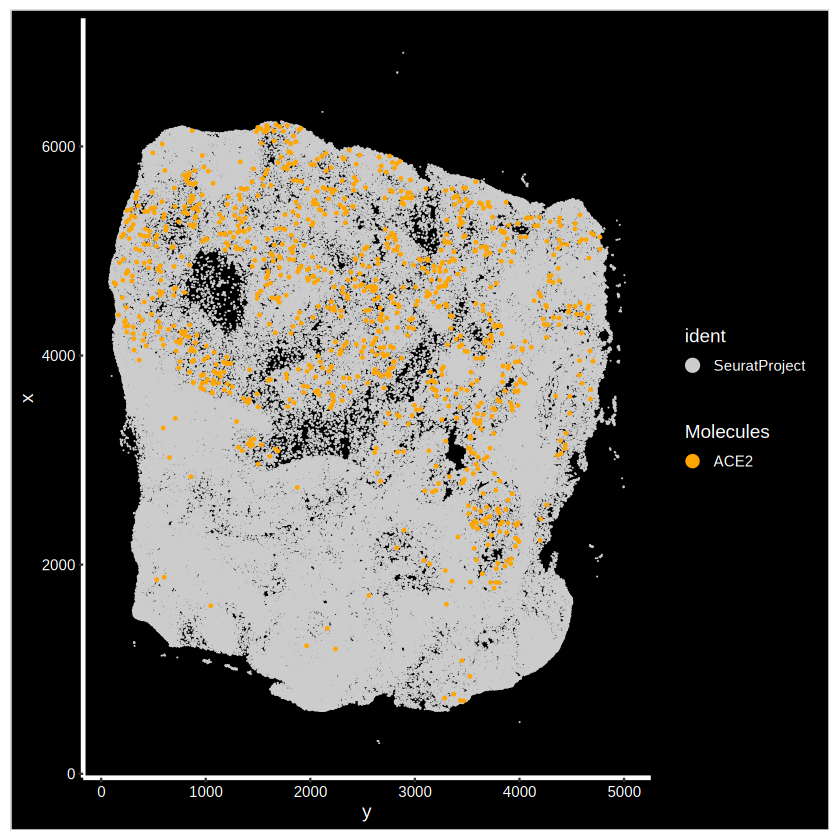

In [5]:
# fetch transcripts for one gene; only the chunks covering ACE2's rows are read from disk
profile_operation("LoadAteraMolecules: ACE2", {
  atera.obj.bp <- LoadAteraMolecules(atera.obj.bp, genes = "ACE2")
})

ImageDimPlot(
  atera.obj.bp,
  fov = "fov",
  size = 0.3,
  cols = "grey80",
  axes = TRUE,
  molecules = "ACE2",
  mols.size = 0.3,
  mols.cols = "orange"
)

⏱️  Starting: Cropped ImageDimPlot: ACE2


Warning message:
“Key ‘Atera_’ taken, using ‘fovcrop_’ instead”



📊 Profile: Cropped ImageDimPlot: ACE2
   Duration:  29.36 seconds
   CPU avg:   67.1%
   RAM Δ:     -483.1 MB



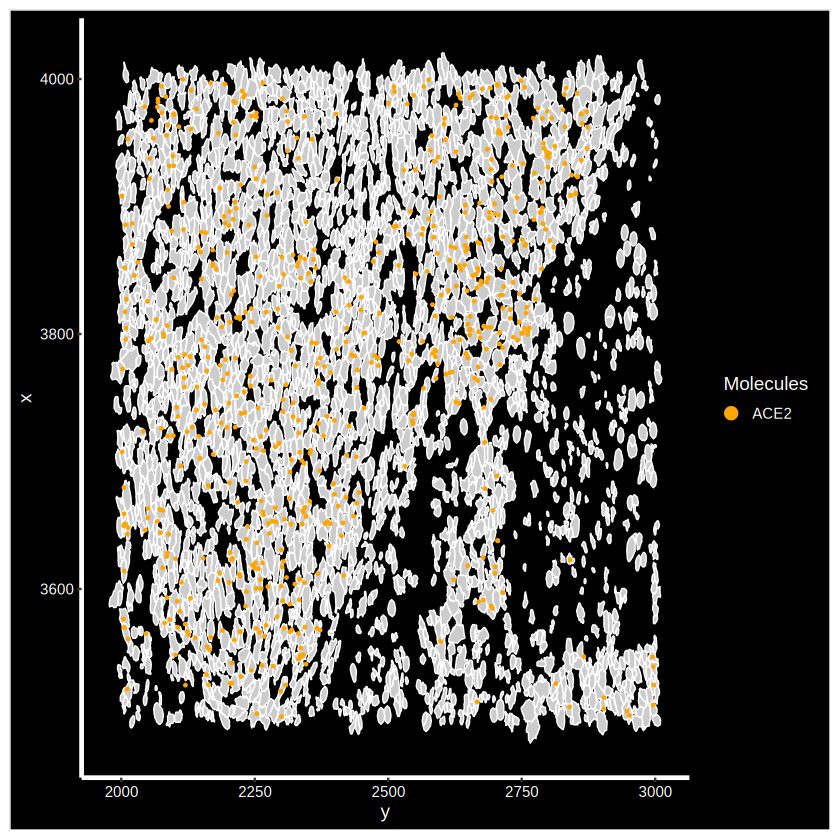

In [10]:
profile_operation("Cropped ImageDimPlot: ACE2", {
  atera.obj.bp[["fov.crop"]] <- Crop(
    atera.obj.bp[["fov"]],
    x = c(3500, 4000),
    y = c(2000, 3000),
    coords = "tissue"
  )

  plot <- ImageDimPlot(
    atera.obj.bp,
    fov = "fov.crop",
    boundaries = "segmentations", # remove this to only plot the centroids
    size = 0.3,
    cols = "grey80",
    axes = TRUE,
    molecules = "ACE2",
    mols.size = 0.3,
    mols.cols = "orange",
    coord.fixed = FALSE,
  )
})
plot

⏱️  Starting: Full ImageDimPlot

📊 Profile: Full ImageDimPlot
   Duration:  64.71 seconds
   CPU avg:   62.7%
   RAM Δ:     +686.0 MB



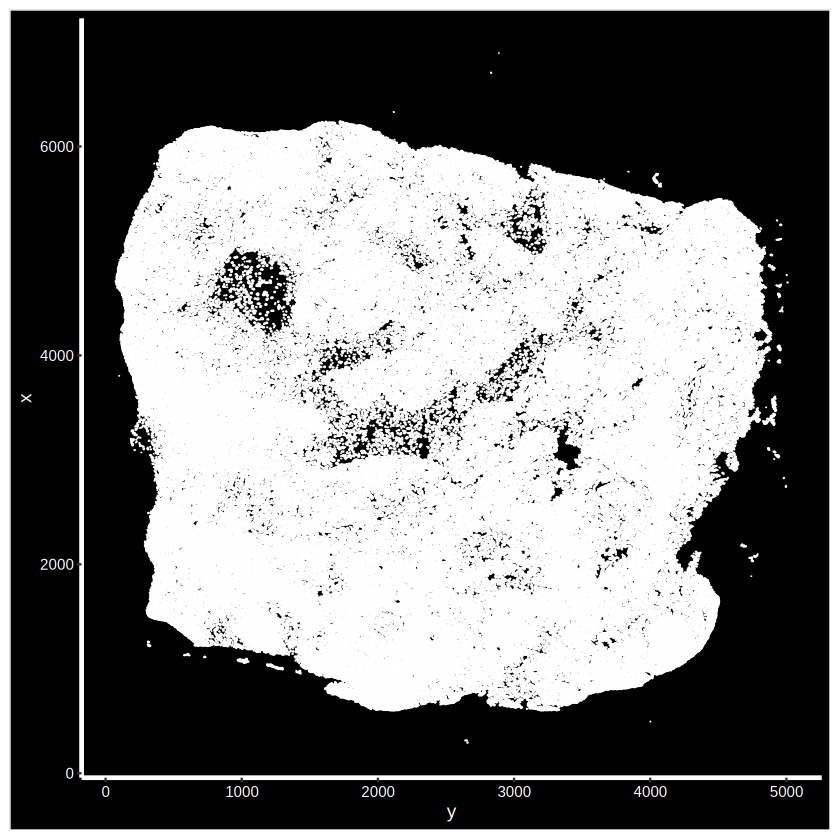

In [ ]:
profile_operation("Full ImageDimPlot", {

  plot <- ImageDimPlot(
    atera.obj.bp,
    fov = "fov",
    boundaries = "segmentations", # remove this to only plot the centroids
    size = 0.1,
    cols = "grey80",
    axes = TRUE,
    coord.fixed = FALSE,
  )
})
plot


⏱️  Starting: LoadAteraMolecules: ACE2 + EPCAM


Warning message:
“Overwriting miscellanous data for atera.molecules”



📊 Profile: LoadAteraMolecules: ACE2 + EPCAM
   Duration:  9.83 seconds
   CPU avg:   84.7%
   RAM Δ:     +466.0 MB



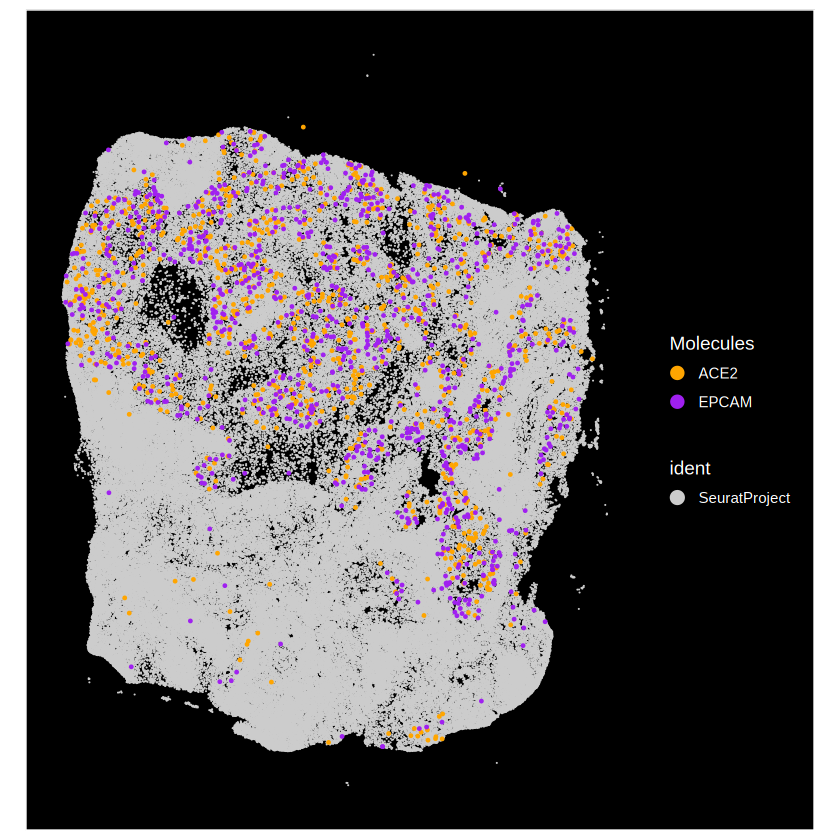

In [7]:
# fetching a second gene skips re-reading ACE2 (already cached); only EPCAM's rows are
# read from disk
profile_operation("LoadAteraMolecules: ACE2 + EPCAM", {
  atera.obj.bp <- LoadAteraMolecules(atera.obj.bp, genes = c("ACE2", "EPCAM"))
})

ImageDimPlot(
  atera.obj.bp,
  fov = "fov",
  size = 0.3,
  cols = "grey80",
  molecules = c("ACE2", "EPCAM"),
  mols.size = 0.3,
  mols.cols = c("orange", "purple")
)

## Basic QC and spatial plotting

Warning message:
“Default search for "data" layer in "Atera" assay yielded no results; utilizing "counts" layer instead.”
Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



[[1]]

[[2]]


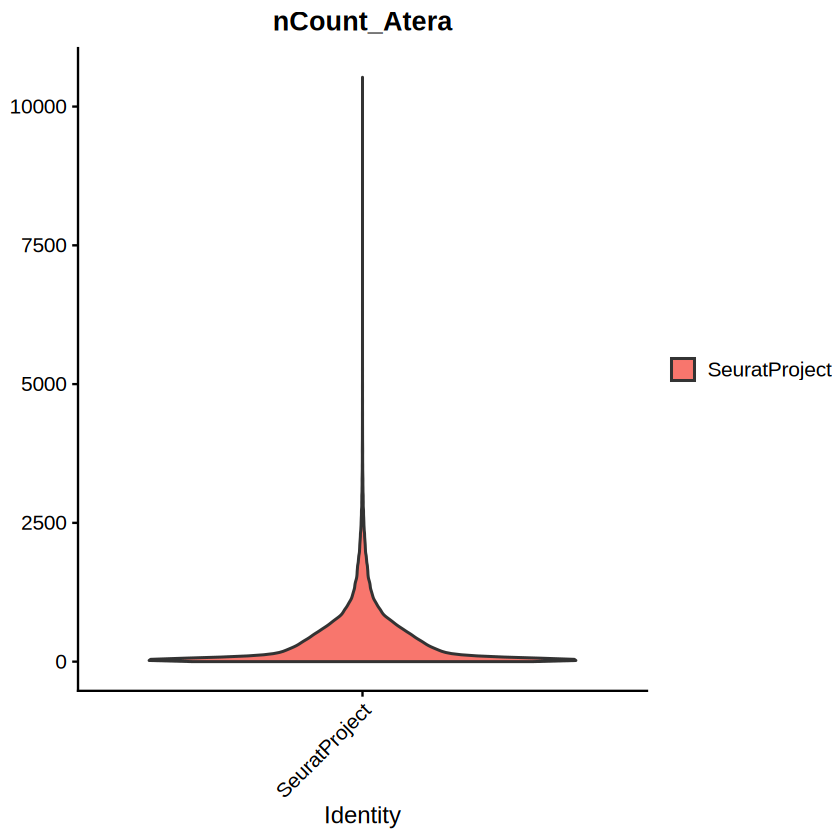

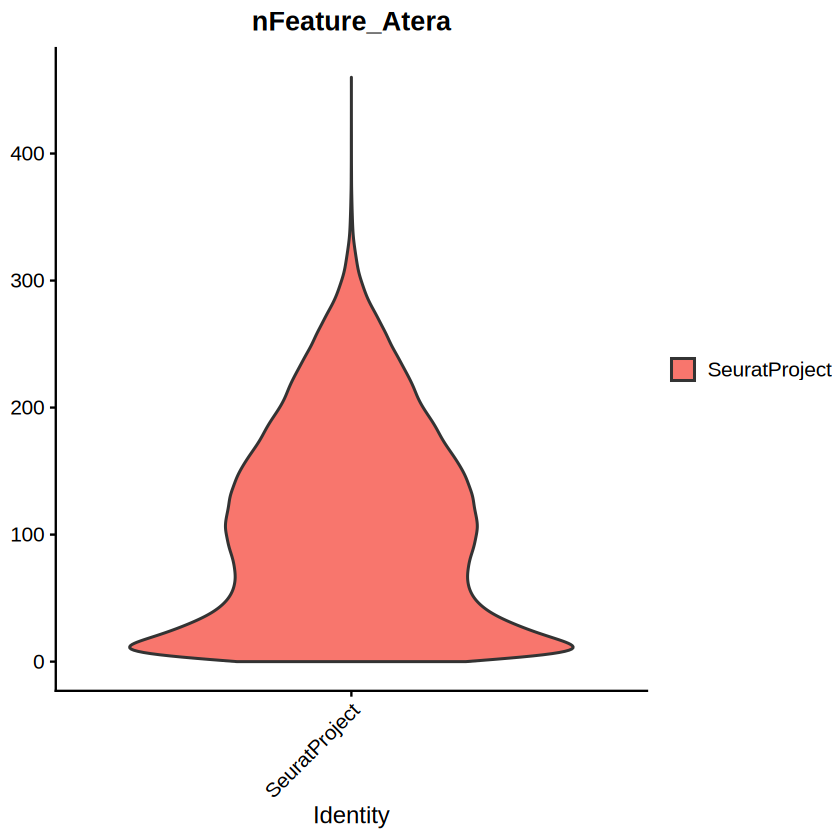

In [12]:
VlnPlot(atera.obj.bp, features = c("nCount_Atera", "nFeature_Atera"), pt.size = 0, combine = FALSE)

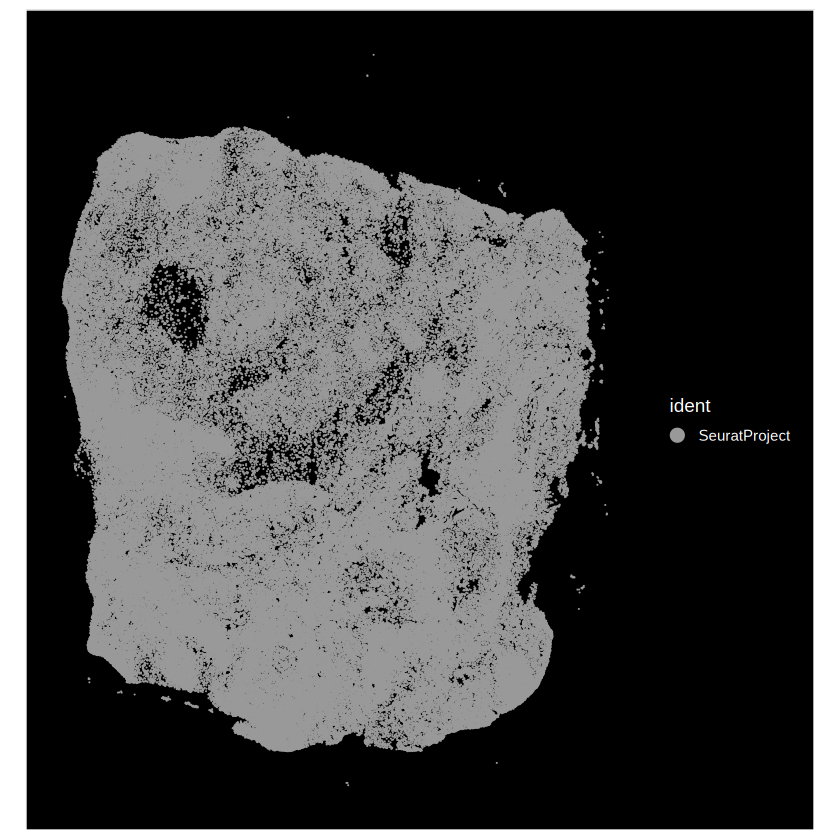

In [12]:
# all cell centroids, no coloring
ImageDimPlot(atera.obj.bp, fov = "fov", size = 0.3, cols = "grey60")

Warning message:
“No layers found matching search pattern provided”
Warning message in FetchData.Assay5(object = object[[DefaultAssay(object = object)]], :
“data layer is not found and counts layer is used”


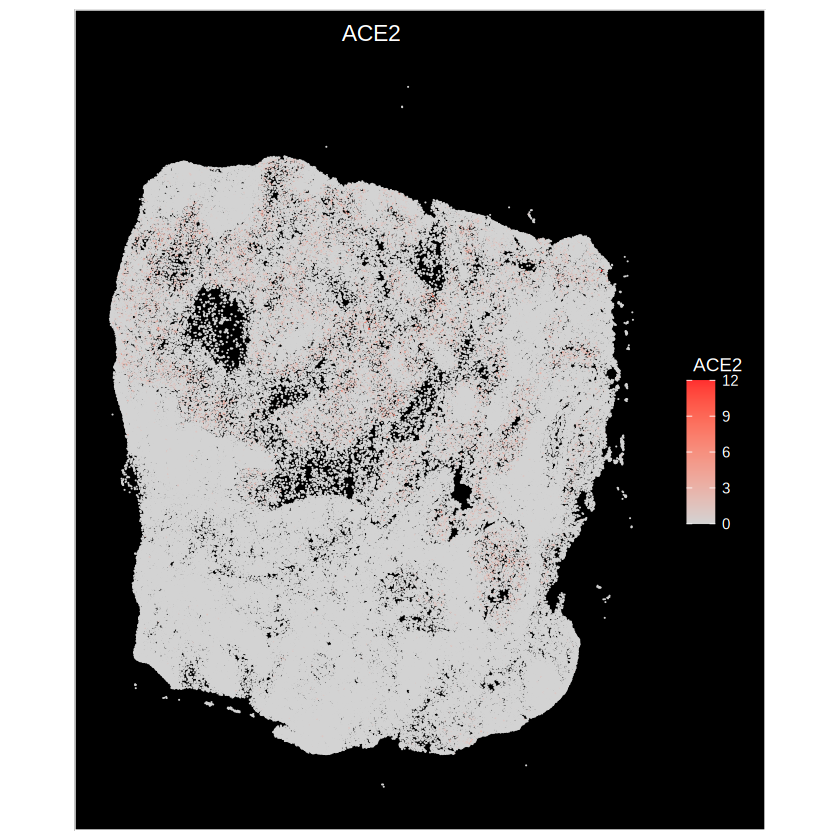

In [13]:
# expression of a panel gene over the tissue
ImageFeaturePlot(atera.obj.bp, fov = "fov", features = "ACE2", size = 0.3)

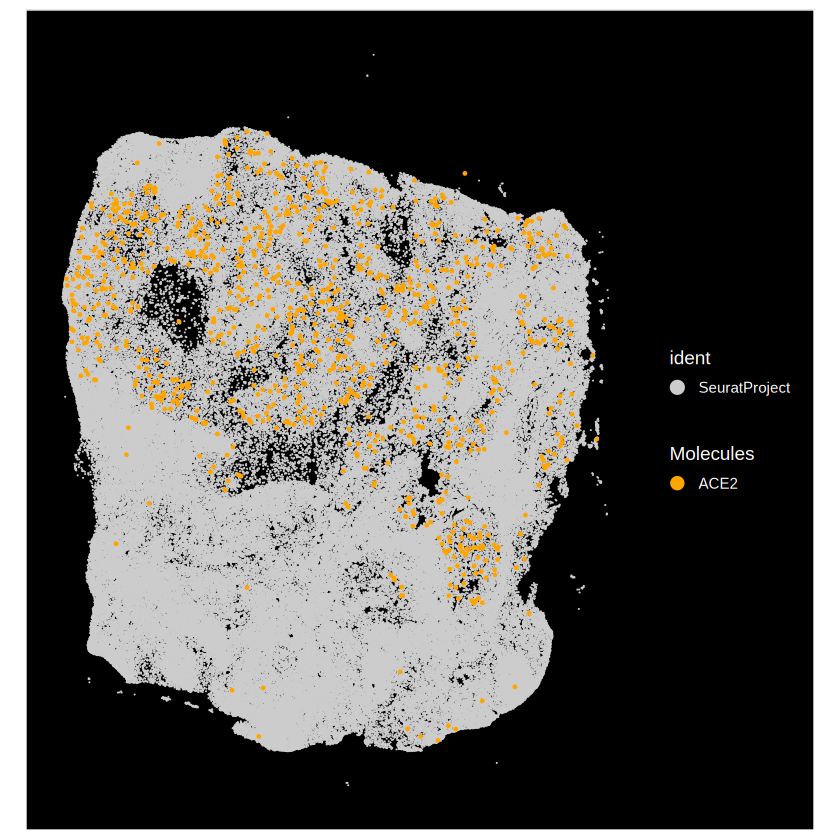

In [14]:
# individual transcript calls for one gene, overlaid on cell centroids
ImageDimPlot(
  atera.obj.bp,
  fov = "fov",
  size = 0.3,
  cols = "grey80",
  molecules = "ACE2",
  mols.size = 0.3,
  mols.cols = "orange"
)

## Not sketching: full-data normalization, PCA, and clustering

Standard Seurat workflow on the Gene Expression counts matrix, run directly on all
~212K cells (no subsampling). `atera.obj.bp` is BPCells-backed (see above), so this runs
against an `IterableMatrix`, streaming from the on-disk cache rather than holding
everything in memory at once. See the "Sketching" section further down for a
faster-clustering alternative on much larger cell counts.

In [13]:
profile_operation("Normalize Data", {
    atera.obj.bp <- NormalizeData(atera.obj.bp)
})
profile_operation("Find Variable Features", {
    atera.obj.bp <- FindVariableFeatures(atera.obj.bp)
})
profile_operation("Scale Data", {
    atera.obj.bp <- ScaleData(atera.obj.bp)
})
profile_operation("Run PCA", {
    atera.obj.bp <- RunPCA(atera.obj.bp, npcs = 30)
})

⏱️  Starting: Normalize Data


Normalizing layer: counts




📊 Profile: Normalize Data
   Duration:  2.25 seconds
   CPU avg:   59.3%
   RAM Δ:     -120.4 MB

⏱️  Starting: Find Variable Features


Finding variable features for layer counts




📊 Profile: Find Variable Features
   Duration:  2.99 seconds
   CPU avg:   56.6%
   RAM Δ:     +0.3 MB

⏱️  Starting: Scale Data


Centering and scaling data matrix




📊 Profile: Scale Data
   Duration:  2.67 seconds
   CPU avg:   54.6%
   RAM Δ:     +0.1 MB

⏱️  Starting: Run PCA


PC_ 1 
Positive:  TFAP2A, FOXA1, EHF, TP63, TMPRSS4, ST6GALNAC1, PITX1, TRIM29, PKP1, SOX2 
	   ERBB3, UPK1B, DSC3, FGFR3, FGFR2, EPCAM, ABCA13, GPRC5A, CALML3, LAMA3 
	   LAMB3, HES1, CDH1, GPC3, SOX4, DSG3, MECOM, COL17A1, DLX5, SERPINB5 
Negative:  CD74, MZB1, CD79A, IL10RA, IRF4, ITGB2, DERL3, PECAM1, CD27, CXCR4 
	   POU2AF1, CD38, SFRP2, ITGAL, SLAMF7, FCRL5, CYTIP, IL2RG, POU2F2, VSIR 
	   PLCG2, FGD2, LY9, TRAC, CD4, PTPRC, TNFRSF1B, WDFY4, CD14, COL5A1 
PC_ 2 
Positive:  TGFB1, CD74, TGFBR2, PTPRC, CD4, ENTPD1, TNFRSF1B, PTEN, STAT1, SERPINB9 
	   TCF4, STAT3, IRF3, ENG, IL2RG, ICAM1, IL10RA, NFKB2, ITGB2, IRF1 
	   ITGAL, MEF2C, VSIR, IRF8, STAT2, IFI30, NOTCH1, ITGA4, CYTIP, RUNX3 
Negative:  CALML3, SOX2, PITX1, TRIM29, SLC2A1, EPCAM, TMPRSS4, EHF, UPK1B, TFAP2A 
	   PKP1, DSG3, DSC3, SERPINB2, CDH1, GPRC5A, PRSS22, MUC4, LYPD3, ERBB3 
	   KRT7, TP63, FOXA1, FGFBP1, COL17A1, ST6GALNAC1, LAMB3, SERPINB5, TMPRSS2, LIPH 
PC_ 3 
Positive:  PTPRC, ITGAL, IL2RG, IL10RA, TRAC, ITG


📊 Profile: Run PCA
   Duration:  31.71 seconds
   CPU avg:   53.1%
   RAM Δ:     +1.0 MB



PC_ 1 
Positive:  TFAP2A, FOXA1, EHF, TP63, TMPRSS4, ST6GALNAC1, PITX1, TRIM29, PKP1, SOX2 
	   ERBB3, UPK1B, DSC3, FGFR3, FGFR2, EPCAM, ABCA13, GPRC5A, CALML3, LAMA3 
	   LAMB3, HES1, CDH1, GPC3, SOX4, DSG3, MECOM, COL17A1, DLX5, SERPINB5 
Negative:  CD74, MZB1, CD79A, IL10RA, IRF4, ITGB2, DERL3, PECAM1, CD27, CXCR4 
	   POU2AF1, CD38, SFRP2, ITGAL, SLAMF7, FCRL5, CYTIP, IL2RG, POU2F2, VSIR 
	   PLCG2, FGD2, LY9, TRAC, CD4, PTPRC, TNFRSF1B, WDFY4, CD14, COL5A1 
PC_ 2 
Positive:  CALML3, SOX2, PITX1, TRIM29, SLC2A1, EPCAM, TMPRSS4, EHF, UPK1B, TFAP2A 
	   PKP1, DSG3, DSC3, SERPINB2, CDH1, GPRC5A, PRSS22, MUC4, LYPD3, ERBB3 
	   KRT7, TP63, FOXA1, FGFBP1, COL17A1, ST6GALNAC1, LAMB3, SERPINB5, TMPRSS2, LIPH 
Negative:  TGFB1, CD74, TGFBR2, PTPRC, CD4, ENTPD1, TNFRSF1B, PTEN, STAT1, SERPINB9 
	   TCF4, STAT3, IRF3, ENG, IL2RG, ICAM1, IL10RA, NFKB2, ITGB2, IRF1 
	   ITGAL, MEF2C, VSIR, IRF8, STAT2, IFI30, NOTCH1, ITGA4, CYTIP, RUNX3 
PC_ 3 
Positive:  COL4A1, CDH5, MCAM, MMRN2, CD34, ADGRF

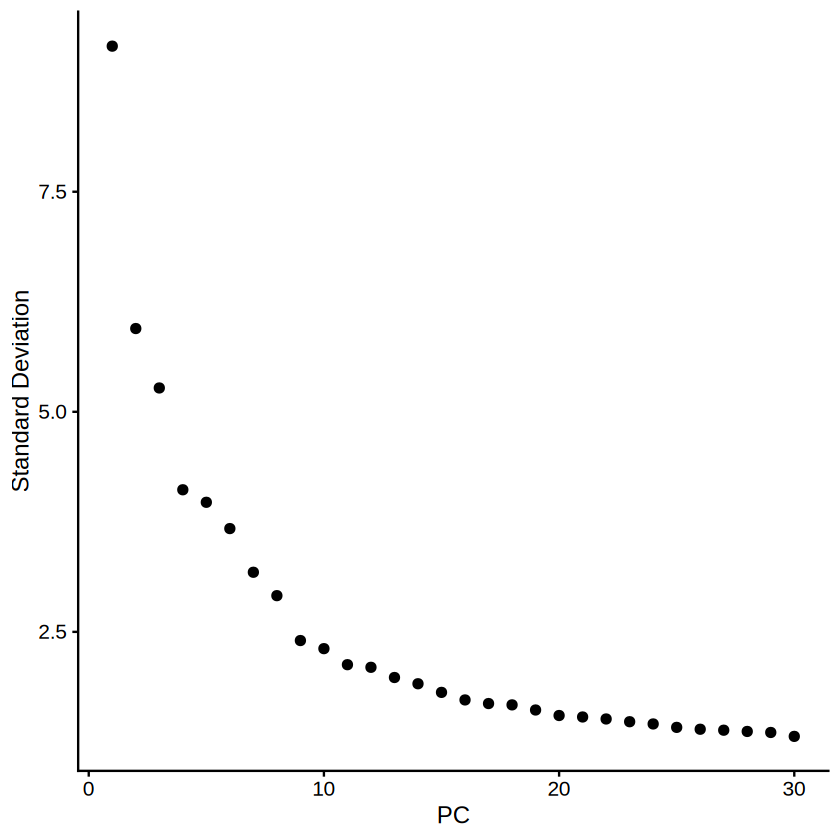

In [ ]:
ElbowPlot(atera.obj.bp, ndims = 30)

In [ ]:
profile_operation("Find Neighbors", {
    atera.obj.bp <- FindNeighbors(atera.obj.bp, dims = 1:30)
})
profile_operation("Find Clusters", {
    atera.obj.bp <- FindClusters(atera.obj.bp, resolution = 1.0)
})

⏱️  Starting: Find Neighbors


Computing nearest neighbor graph

Computing SNN




📊 Profile: Find Neighbors
   Duration:  94.13 seconds
   CPU avg:   52.0%
   RAM Δ:     +265.4 MB



Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
20:24:27 UMAP embedding parameters a = 0.9922 b = 1.112

20:24:27 Read 212396 rows and found 30 numeric columns

20:24:27 Using Annoy for neighbor search, n_neighbors = 30

20:24:27 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

20:24:52 Writing NN index file to temp file /tmp/RtmpjpnzDE/file61e205e468236

20:24:52 Searching Annoy index using 1 thread, search_k = 3000

20:26:28 Annoy recall = 97.13%

20:26:28 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighb

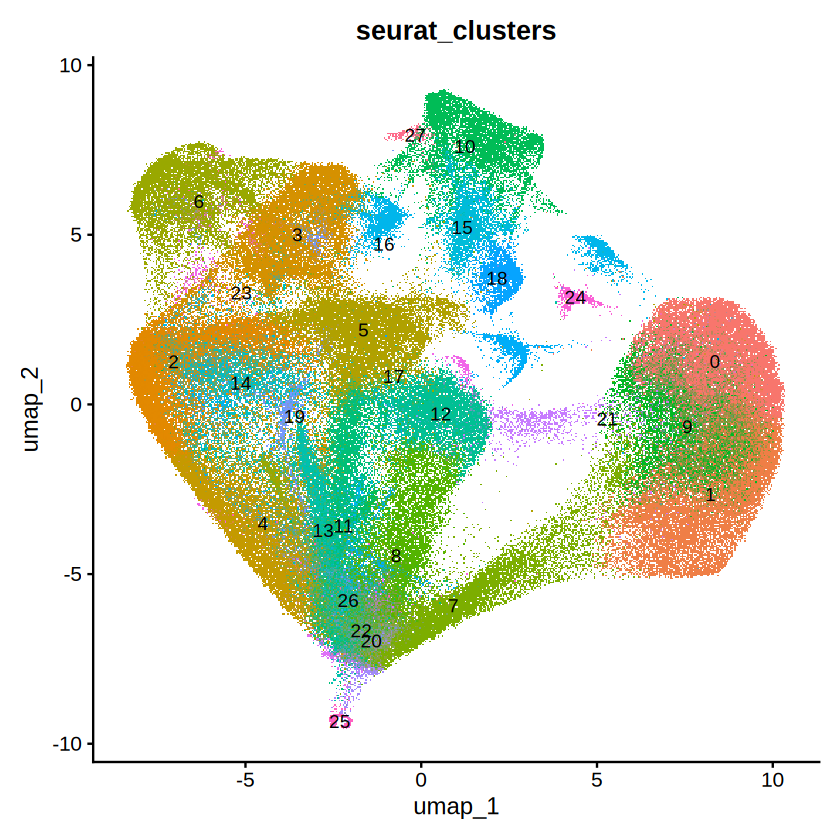

In [18]:
atera.obj.bp <- RunUMAP(atera.obj.bp, dims = 1:30)
DimPlot(atera.obj.bp, group.by = "seurat_clusters", label = TRUE) + NoLegend()

## Plot clusters over the tissue

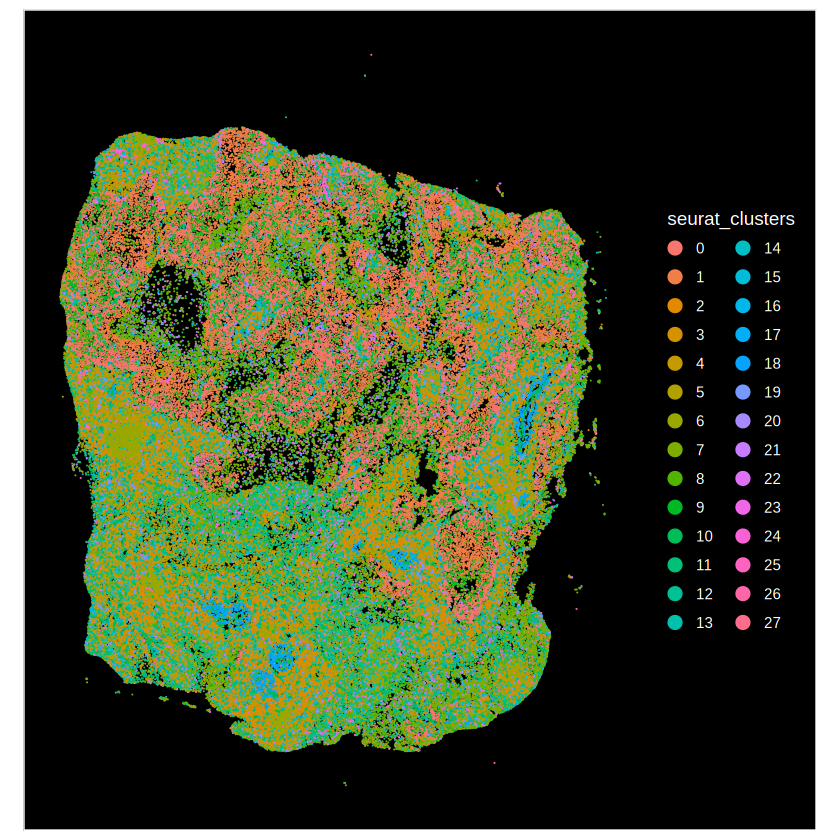

In [ ]:
profile_operation("Full ImageDimPlot with Clusters", {
    ImageDimPlot(atera.obj.bp, fov = "fov", group.by = "seurat_clusters", size = 0.3)
})

## Customizing further: feature-type scoping

`atera.obj.bp` above decodes/caches **all** feature types (Gene Expression plus the
control/codeword types) on first build, even though most downstream analysis only
touches Gene Expression. Pass `feature.types = "Gene Expression"` (or any subset) to
`LoadAtera`/`ReadAtera` to restrict decoding (and caching) to just the type(s) you need —
feature types occupy contiguous row ranges in the underlying zarr array, so this skips
decompressing chunks for types you don't need at all, rather than materializing and then
discarding them. See `?ReadAtera` for details.

## Sketching: scaling clustering to large cell counts

`FindClusters` on the full ~212K-cell dataset above (see the "Not sketching" section
— specifically the "Louvain algorithm" cell under Normalization/PCA/clustering) took
roughly 15 minutes, dominated by clustering cost itself rather than I/O — this only gets
worse on Atera's larger whole-transcriptome bundles (potentially millions of cells).

Seurat5's sketch-based workflow (see the
[seurat5_sketch_analysis](https://satijalab.org/seurat/articles/seurat5_sketch_analysis)
vignette) addresses this: subsample a small, statistically representative "sketch" of
cells via leverage-score weighting (`SketchData`), run the expensive
normalize/PCA/cluster/UMAP steps on just the sketch, then project the results (PCA
embedding, UMAP, cluster/label assignments) back onto the full dataset
(`ProjectData`/`TransferSketchLabels`). `LeverageScore` (called internally by
`SketchData`) has a dedicated `IterableMatrix` code path, so this works directly on
`atera.obj.bp` — no extra adaptation needed.

⏱️  Starting: SketchData


Calcuating Leverage Score

Running LeverageScore for layer data

No variable features were found in data. Falling back to variable features from counts

sampling 5000 cells for random sketching

Performing QR decomposition

Performing random projection

Attempting to cast layer counts to dgCMatrix

Attempting to cast layer data to dgCMatrix




📊 Profile: SketchData
   Duration:  77.77 seconds
   CPU avg:   64.4%
   RAM Δ:     +1031.6 MB



Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

PC_ 1 
Positive:  CD74, MZB1, ITGB2, IL10RA, CD79A, CXCR4, IRF4, CD27, PECAM1, ITGAL 
	   DERL3, SFRP2, POU2AF1, SLAMF7, IL2RG, CD4, CYTIP, TRAC, CD38, TNFRSF1B 
	   VSIR, PTPRC, POU2F2, FCRL5, LY9, COL5A1, FGD2, PLCG2, WDFY4, CIITA 
Negative:  TFAP2A, EHF, FOXA1, TP63, TMPRSS4, ST6GALNAC1, PITX1, TRIM29, SOX2, PKP1 
	   UPK1B, ERBB3, FGFR3, EPCAM, FGFR2, DSC3, CALML3, LAMA3, GPRC5A, ABCA13 
	   LAMB3, CDH1, COL17A1, GPC3, HES1, DSG3, SERPINB5, SOX4, DLX5, MECOM 
PC_ 2 
Positive:  CALML3, SLC2A1, SOX2, TRIM29, SERPINB2, EPCAM, PRSS22, PITX1, UPK1B, DSG3 
	   TMPRSS4, LYPD3, APOBEC3A, TCN1, DSC3, DUOX2, GPRC5A, KRT7, EHF, PKP1 
	   PRAC1, LIPH, TFAP2A, FGFBP1, FOXA1, C20orf85, CDH1, IL1A, HMGCS2, TMPRSS2 
Negative:  TGFBR2, ENG, TGFB1, STAT3, TCF4, ENTPD1, ITGB1, PTEN, SERPINB9, FBN1 
	   CD4, TNFRSF1B, ITGA1, COL4A1, STAT1, CD74, SH2D3C, ICAM1, NRP1, NFKB2 
	   NOTCH1, MYLK, CAV1, 

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 5000
Number of edges: 190484

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8414
Number of communities: 17
Elapsed time: 4 seconds


UMAP will return its model

20:32:17 UMAP embedding parameters a = 0.9922 b = 1.112

20:32:17 Read 5000 rows and found 30 numeric columns

20:32:17 Using Annoy for neighbor search, n_neighbors = 30

20:32:17 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

20:32:17 Writing NN index file to temp file /tmp/RtmpjpnzDE/file61e20307974cb

20:32:17 Searching Annoy index using 1 thread, search_k = 3000

20:32:18 Annoy recall = 100%

20:32:19 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

20:32:20 Initializing from normalized Laplacian + noise (using RSpectra)

20:32:20 Commencing optimization for 500 epochs, with 217662 positive edges

20:32:20 Using rng type: pcg

20:32:27 Optimization finished

Warning message:
“Number of cells chang

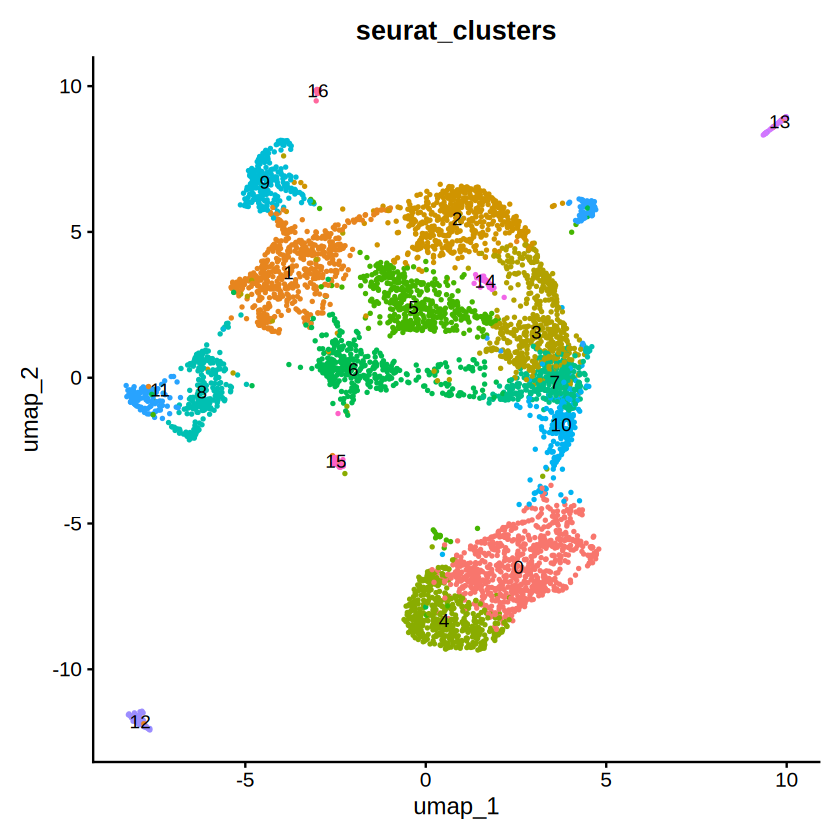

In [20]:
# Subsample ~5000 cells via leverage-score weighting; work on the small sketch assay
profile_operation("SketchData", {
  atera.obj.bp <- SketchData(
    object = atera.obj.bp,
    assay = "Atera",
    ncells = 5000L,
    sketched.assay = "sketch"
  )
})
DefaultAssay(atera.obj.bp) <- "sketch"

atera.obj.bp <- NormalizeData(atera.obj.bp)
atera.obj.bp <- FindVariableFeatures(atera.obj.bp)
atera.obj.bp <- ScaleData(atera.obj.bp)
atera.obj.bp <- RunPCA(atera.obj.bp, npcs = 30)
atera.obj.bp <- FindNeighbors(atera.obj.bp, dims = 1:30)
atera.obj.bp <- FindClusters(atera.obj.bp, resolution = 1.0)
atera.obj.bp <- RunUMAP(atera.obj.bp, dims = 1:30, return.model = TRUE)

DimPlot(atera.obj.bp, group.by = "seurat_clusters", label = TRUE) + NoLegend()

⏱️  Starting: ProjectData


pca.full is not in the object. Data from all cells will be projected to pca

Projecting cell embeddings

Finding sketch neighbors

Finding sketch weight matrix

Transfering refdata from sketch

Projection to sketch umap

Running UMAP projection

20:33:30 Read 212396 rows

20:33:30 Processing block 1 of 1

20:33:30 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

20:33:32 Initializing by weighted average of neighbor coordinates using 1 thread

20:33:33 Commencing optimization for 167 epochs, with 6371880 positive edges

20:34:30 Finished

Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from full.umap to fullumap_”



📊 Profile: ProjectData
   Duration:  119.15 seconds
   CPU avg:   70.1%
   RAM Δ:     +911.5 MB



Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



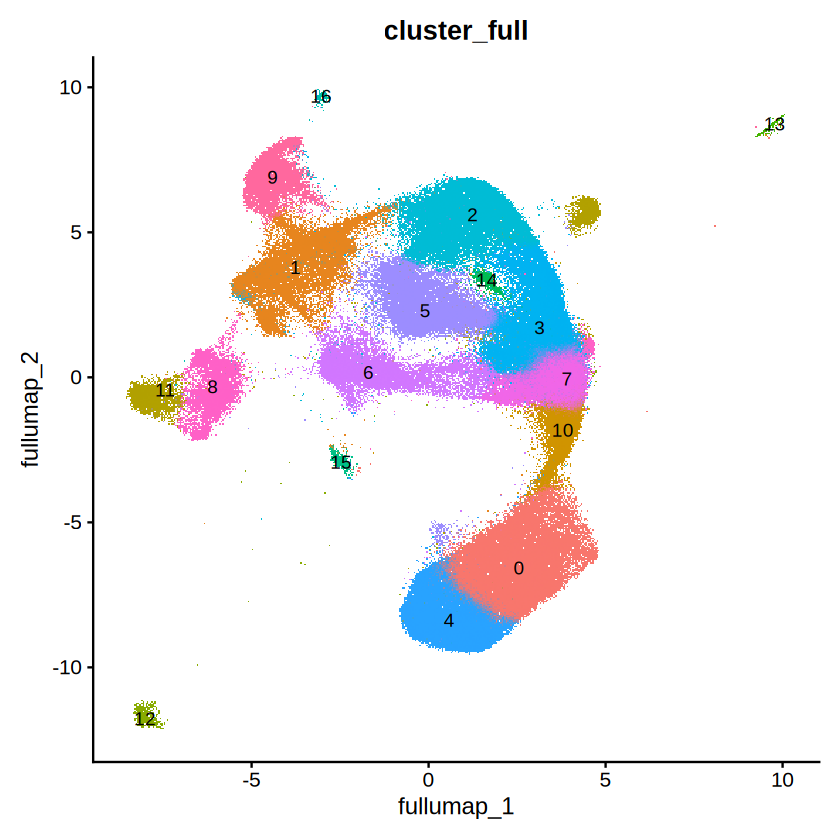

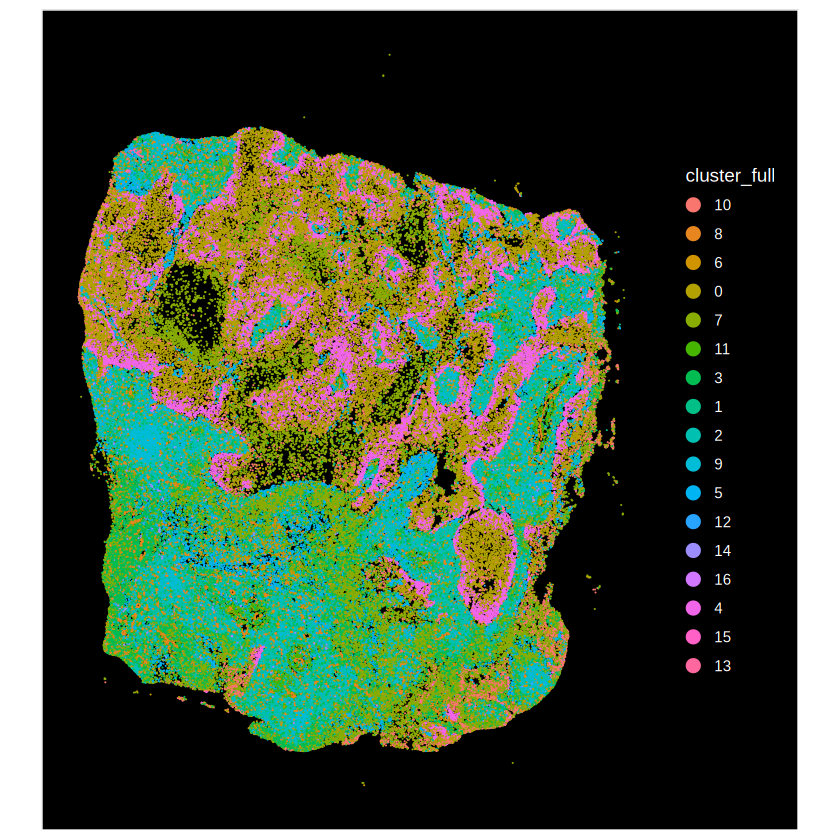

In [21]:
# Project the sketch's PCA/UMAP and cluster labels back onto all full-data cells
profile_operation("ProjectData", {
  atera.obj.bp <- ProjectData(
    object = atera.obj.bp,
    assay = "Atera",
    sketched.assay = "sketch",
    sketched.reduction = "pca",
    full.reduction = "pca.full",
    dims = 1:30,
    umap.model = "umap",
    refdata = list(cluster_full = "seurat_clusters")
  )
})
DefaultAssay(atera.obj.bp) <- "Atera"

DimPlot(atera.obj.bp, reduction = "full.umap", group.by = "cluster_full", label = TRUE) +
  NoLegend()
ImageDimPlot(atera.obj.bp, fov = "fov", group.by = "cluster_full", size = 0.3)